In [1]:
import pandas as pd
import numpy as np

In [7]:
sales = pd.read_csv("../data/Sales-UTF8.csv", sep=";", engine="python")
states = pd.read_csv("../data/States-UTF8.csv", sep=";", engine="python")

In [8]:
sales.head()

,Category,City,Container,Customer ID,Customer Name,Customer Segment,Department,Item ID,Item,Order Date,...,Ship Date,Ship Mode,State,Discount,Order Quantity,Product Base Margin,Profit,Sales,Shipping Cost,Unit Price
0,Paper,Lombard,Small Box,3035,Mark Bailey,Home Office,Office Supplies,10074,Hammermill CopyPlus Copy Paper (20Lb. and 84 B...,11/08/2016,...,11/09/2016,Regular Air,Illinois,0.01,10,0.36,-76,53,5,5
1,Paper,Lombard,Wrap Bag,3035,Mark Bailey,Home Office,Office Supplies,10079,Telephone Message Books with Fax/Mobile Sectio...,11/11/2014,...,11/12/2014,Regular Air,Illinois,0.04,12,0.39,52,76,1,6
2,Pens & Art Supplies,Southbury,Wrap Bag,3385,Daniel Richmond,Corporate,Office Supplies,11012,"Premium Writing Pencils, Soft, #2 by Central A...",11/23/2015,...,11/23/2015,Express Air,Connecticut,0.04,5,0.57,-22,16,2,3
3,Binders and Binder Accessories,Coachella,Small Box,3133,Kristine Singleton,Corporate,Office Supplies,10646,Fellowes Black Plastic Comb Bindings,1/13/2016,...,1/25/2016,Regular Air,California,0.10,12,0.39,-350,65,8,6
4,Rubber Bands,Coachella,Wrap Bag,3133,Kristine Singleton,Corporate,Office Supplies,10138,Assorted Color Push Pins,1/13/2016,...,1/25/2016,Regular Air,California,0.03,10,0.52,4,19,1,2


In [9]:
states.head()

,State or territory,Population estimate (2016),Census population (2010),Total seats in House of Representatives (2013–2023),Estimated pop. per House seat (2016),Census pop. per House seat (2010),Percent of total U.S. pop. (2016)
0,California,39268294,37254503,53,738581,702905,12.15%
1,Texas,27862596,25146105,36,763031,698487,8.62%
2,Florida,20612439,18804623,27,750788,696345,6.38%
3,New York,19745289,19378087,27,733177,717707,6.11%
4,Illinois,12801539,12831549,18,714444,712813,3.96%


In [10]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Category             9426 non-null   object 
 1   City                 9426 non-null   object 
 2   Container            9426 non-null   object 
 3   Customer ID          9426 non-null   int64  
 4   Customer Name        9426 non-null   object 
 5   Customer Segment     9426 non-null   object 
 6   Department           9426 non-null   object 
 7   Item ID              9426 non-null   int64  
 8   Item                 9426 non-null   object 
 9   Order Date           9426 non-null   object 
 10  Order ID             9426 non-null   int64  
 11  Order Priority       9426 non-null   object 
 12  Postal Code          9426 non-null   int64  
 13  Region               9426 non-null   object 
 14  Row ID               9426 non-null   object 
 15  Ship Date            9426 non-null   o

In [15]:
sales.columns


Index(['Category', 'City', 'Container', 'Customer ID', 'Customer Name',
       'Customer Segment', 'Department', 'Item ID', 'Item', 'Order Date',
       'Order ID', 'Order Priority', 'Postal Code', 'Region', 'Row ID',
       'Ship Date', 'Ship Mode', 'State', 'Discount', 'Order Quantity',
       'Product Base Margin', 'Profit', 'Sales', 'Shipping Cost',
       'Unit Price'],
      dtype='object')

In [16]:
sales["Sales"].sum()

np.int64(8952027)

In [19]:
sales["Profit"].sum()

np.int64(1312415)

In [20]:
sales["Category"].unique()

array(['Paper', 'Pens & Art Supplies', 'Binders and Binder Accessories',
       'Rubber Bands', 'Storage & Organization', 'Tables',
       'Office Furnishings', 'Telephones and Communication', 'Labels',
       'Appliances', 'Envelopes', 'Computer Peripherals',
       'Chairs & Chairmats', 'Office Machines', 'Bookcases',
       'Scissors, Rulers and Trimmers', 'Copiers and Fax'], dtype=object)

In [22]:
sales.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Office Machines                   1218655
Chairs & Chairmats                1164586
Telephones and Communication      1144284
Tables                            1061922
Copiers and Fax                    661215
Binders and Binder Accessories     638583
Storage & Organization             585717
Bookcases                          507496
Computer Peripherals               490851
Appliances                         456736
Office Furnishings                 444634
Paper                              253620
Envelopes                          147915
Pens & Art Supplies                103265
Scissors, Rulers and Trimmers       40432
Labels                              23446
Rubber Bands                         8670
Name: Sales, dtype: int64

<Axes: xlabel='Category'>

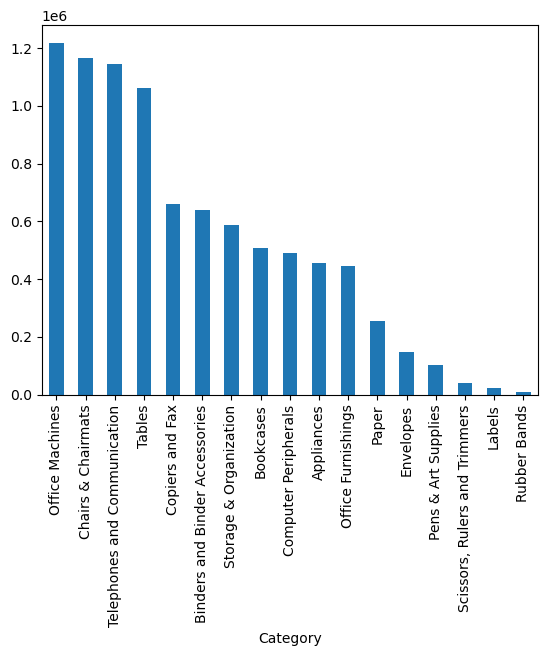

In [25]:
sales.groupby("Category")["Sales"].sum().sort_values(ascending=False).plot(kind="bar")

In [26]:
##on ameliore le graphe 


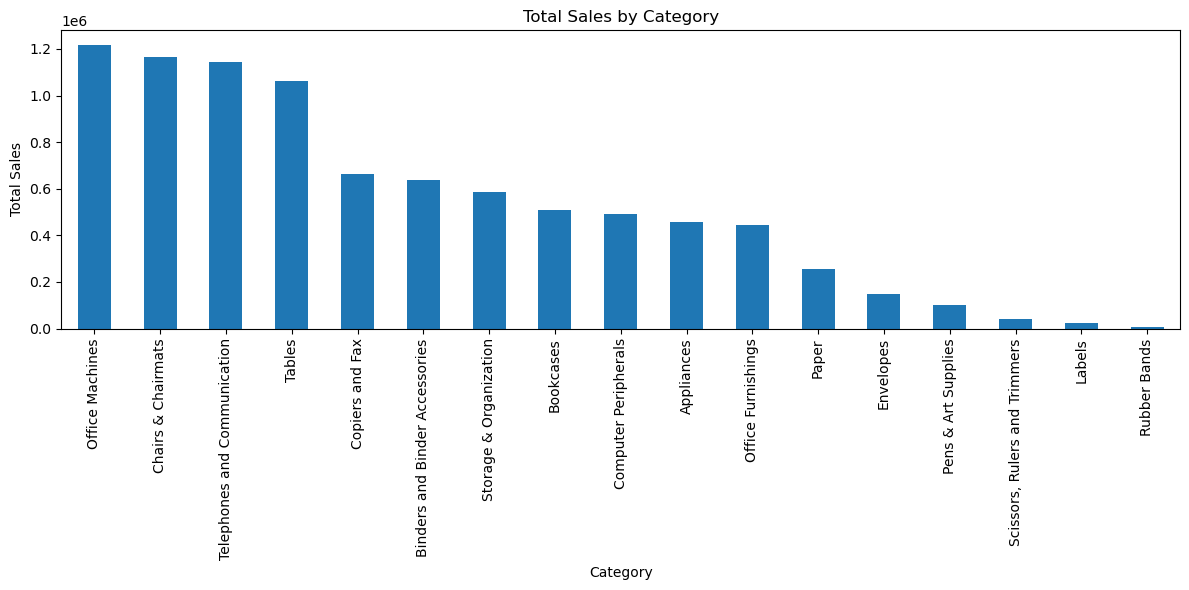

In [29]:
import matplotlib.pyplot as plt

sales.groupby("Category")["Sales"].sum().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [30]:
sales.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Telephones and Communication      297944
Binders and Binder Accessories    226582
Office Machines                   168079
Chairs & Chairmats                165341
Copiers and Fax                   129154
Appliances                        121641
Office Furnishings                 92216
Computer Peripherals               87911
Envelopes                          46133
Paper                              35360
Labels                             17776
Storage & Organization              8071
Pens & Art Supplies                 1202
Scissors, Rulers and Trimmers      -1938
Rubber Bands                       -2837
Bookcases                          -7714
Tables                            -72506
Name: Profit, dtype: int64

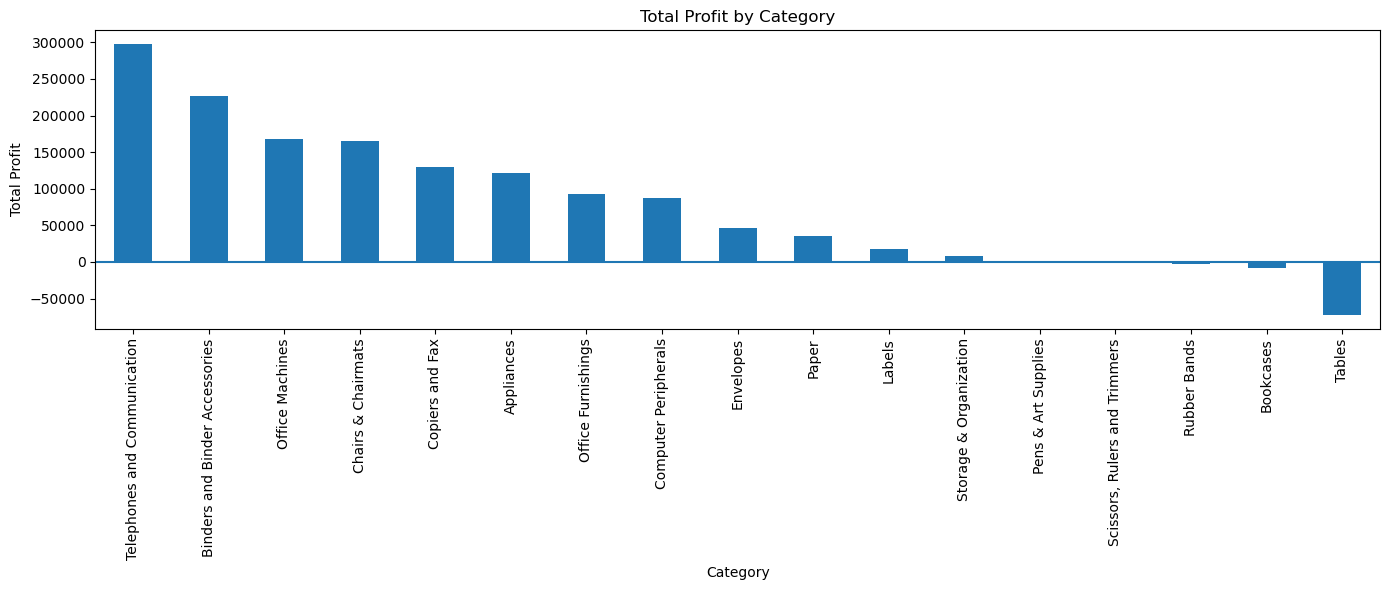

In [37]:
import matplotlib.pyplot as plt

sales.groupby("Category")["Profit"].sum().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(14,6)
)

plt.axhline(0)  

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [38]:
sales["Discount"].unique()

array([0.01, 0.04, 0.1 , 0.03, 0.  , 0.05, 0.02, 0.09, 0.06, 0.08, 0.07,
       0.25, 0.16, 0.11, 0.17, 0.21])

In [39]:
sales.groupby("Discount")["Profit"].mean().sort_index()

Discount
0.00    185.097877
0.01    176.867483
0.02    177.339080
0.03    222.536281
0.04    118.609756
0.05    158.161547
0.06    112.615104
0.07    106.148194
0.08     86.125882
0.09    111.490241
0.10     68.427208
0.11    148.000000
0.16    -75.000000
0.17     -9.000000
0.21    -18.000000
0.25   -481.000000
Name: Profit, dtype: float64

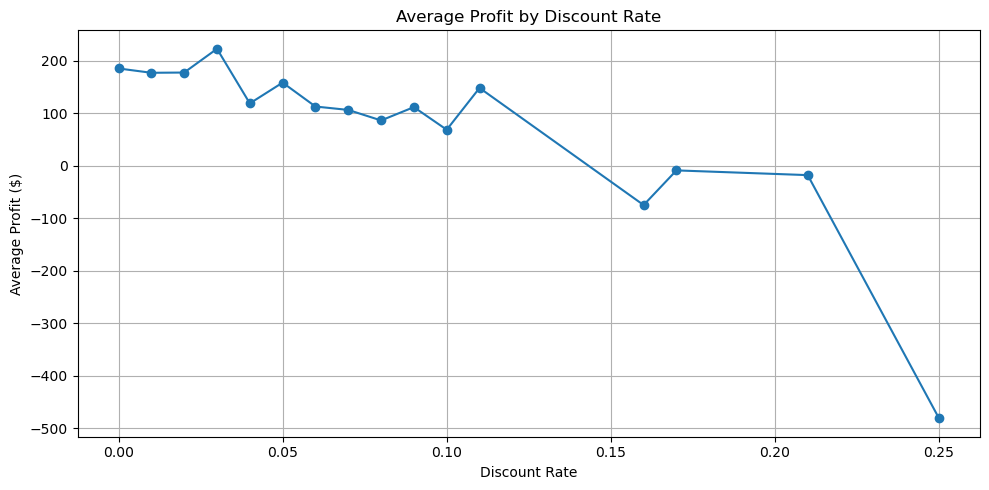

In [41]:
discount_profit = sales.groupby("Discount")["Profit"].mean().sort_index()

discount_profit.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Average Profit by Discount Rate")
plt.xlabel("Discount Rate")
plt.ylabel("Average Profit")
plt.grid(True)
plt.ylabel("Average Profit ($)")

plt.tight_layout()
plt.show()

In [42]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Ship Date"] = pd.to_datetime(sales["Ship Date"])

In [43]:
sales[["Order Date", "Ship Date"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9426 non-null   datetime64[ns]
 1   Ship Date   9426 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 147.4 KB


In [44]:
sales["Shipping Delay"] = (sales["Ship Date"] - sales["Order Date"]).dt.days

In [45]:
sales[["Order Date", "Ship Date", "Shipping Delay"]].head()

,Order Date,Ship Date,Shipping Delay
0,2016-11-08,2016-11-09,1
1,2014-11-11,2014-11-12,1
2,2015-11-23,2015-11-23,0
3,2016-01-13,2016-01-25,12
4,2016-01-13,2016-01-25,12


In [46]:
sales["Shipping Delay"].mean()

np.float64(16.96827922766815)

In [47]:
sales["Order Year"] = sales["Order Date"].dt.year
sales["Order Month"] = sales["Order Date"].dt.month

In [48]:
sales[["Order Date", "Order Year", "Order Month"]].head()

,Order Date,Order Year,Order Month
0,2016-11-08,2016,11
1,2014-11-11,2014,11
2,2015-11-23,2015,11
3,2016-01-13,2016,1
4,2016-01-13,2016,1


In [49]:
sales.groupby("Order Year")["Sales"].sum()

Order Year
2013     371971
2014    1717979
2015    3152871
2016    3709206
Name: Sales, dtype: int64

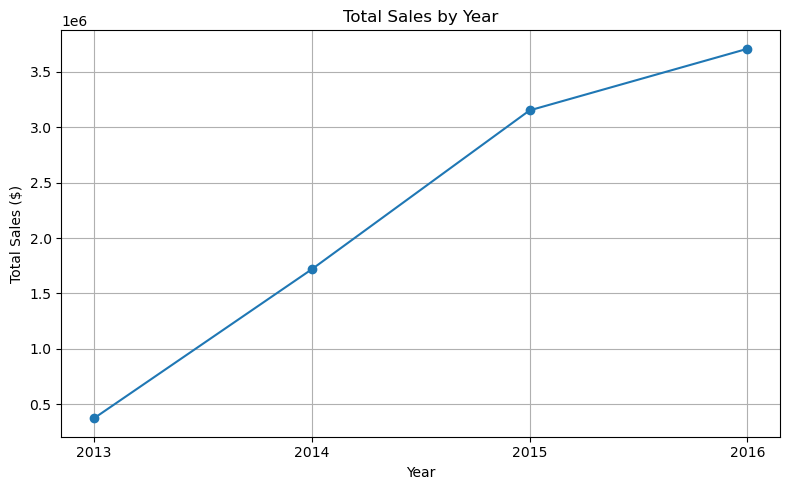

In [52]:
sales.groupby("Order Year")["Sales"].sum().plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")

plt.locator_params(axis='x', integer=True)

plt.grid(True)

plt.tight_layout()
plt.show()

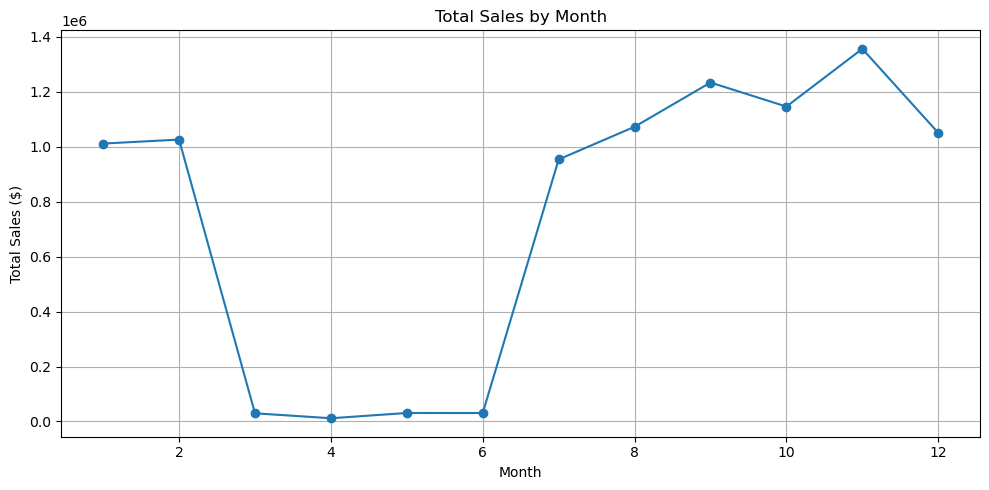

In [53]:
sales.groupby("Order Month")["Sales"].sum().plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")

plt.locator_params(axis='x', integer=True)

plt.grid(True)

plt.tight_layout()
plt.show()

In [55]:
sales_monthly = sales.groupby(["Order Year", "Order Month"])["Sales"].sum().reset_index()

sales_monthly.head()

,Order Year,Order Month,Sales
0,2013,1,30565
1,2013,2,21202
2,2013,3,23176
3,2013,4,10027
4,2013,5,24566


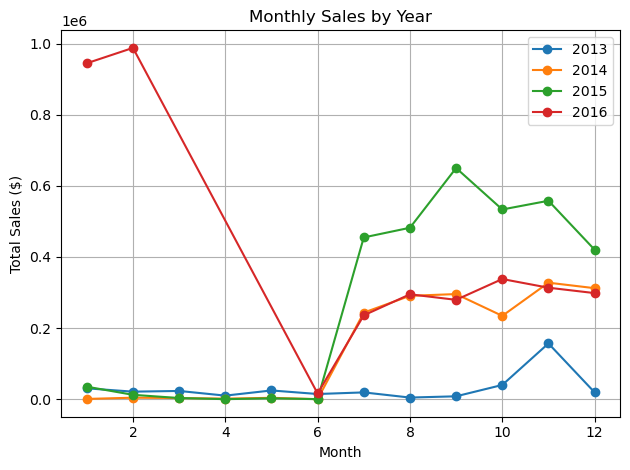

In [56]:
import matplotlib.pyplot as plt

for year in sales_monthly["Order Year"].unique():
    
    yearly_data = sales_monthly[sales_monthly["Order Year"] == year]
    
    plt.plot(
        yearly_data["Order Month"],
        yearly_data["Sales"],
        marker="o",
        label=year
    )

plt.title("Monthly Sales by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")

plt.locator_params(axis='x', integer=True)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [59]:
region_sales = sales.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
East       3143122
Central    2294603
West       2002353
South      1511949
Name: Sales, dtype: int64

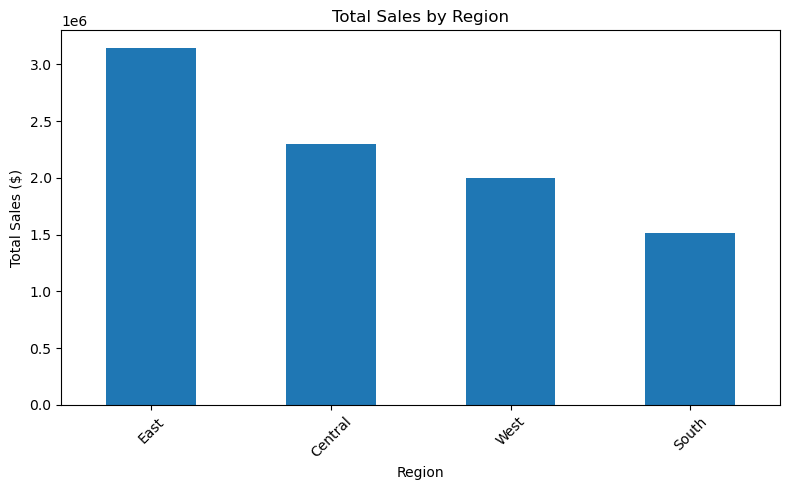

In [60]:
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
region_profit = sales.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_profit

Region
East       475024
Central    458668
West       271578
South      107145
Name: Profit, dtype: int64

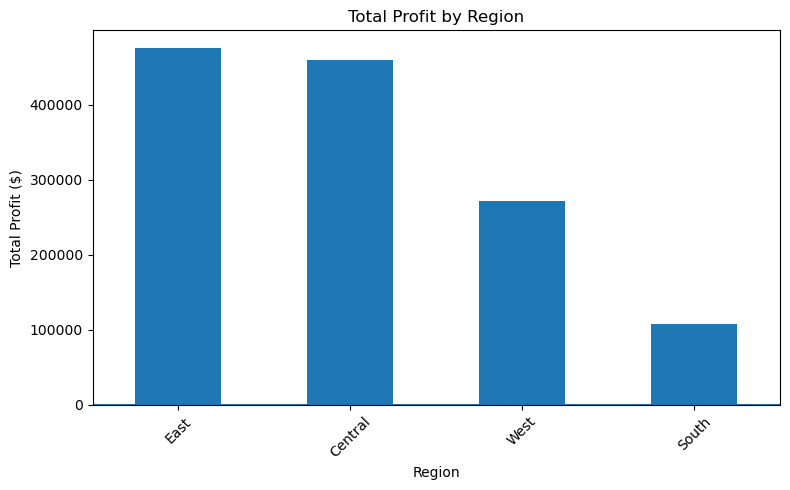

In [62]:
region_profit.plot(kind="bar", figsize=(8,5))

plt.axhline(0)
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
top_cities_sales = sales.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
top_cities_sales

City
Oxford           582583
Boston           415304
Irving           376895
Los Angeles      359718
Washington       218869
Seattle          179569
Miami            178427
New York City    169799
Philadelphia     158445
New City         156604
Name: Sales, dtype: int64

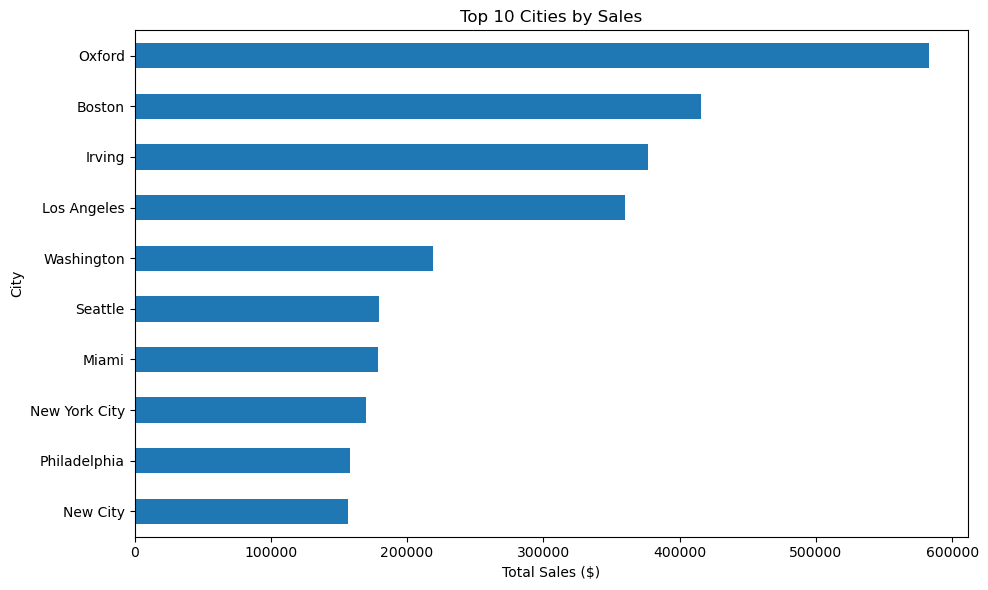

In [64]:
top_cities_sales.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Top 10 Cities by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [65]:
top_customers_sales = sales.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers_sales


Customer Name
Joshua N. Milligan       123748
Glen Caldwell             89272
Rosemary O'Brien          86541
Leigh Burnette Hurley     83651
Kristine Connolly         81296
Nina Horne Kelly          78243
Neal Wolfe                69118
Priscilla Kane            61611
Dana Teague               61299
Kim Weiss                 58947
Name: Sales, dtype: int64

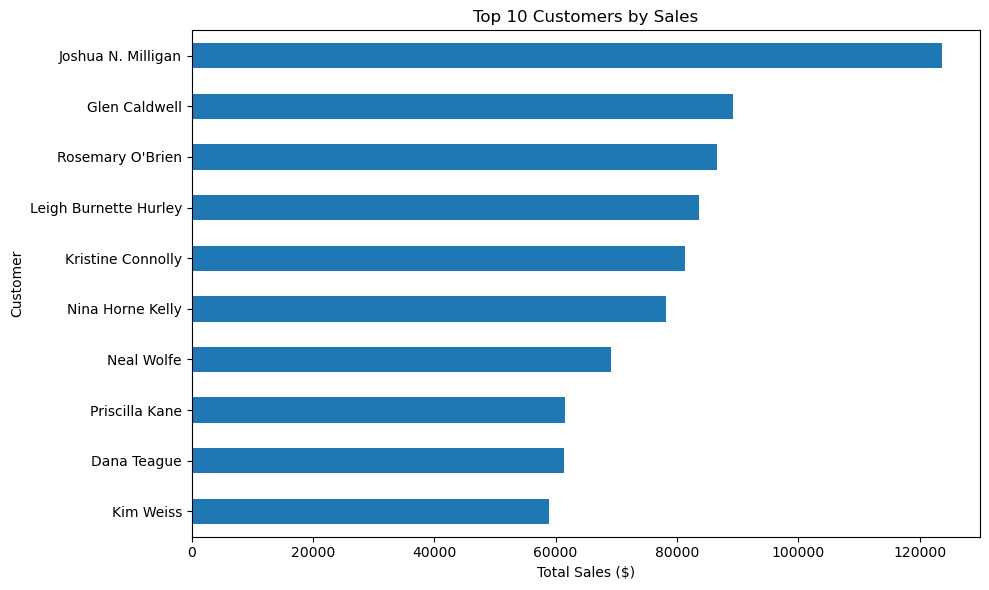

In [66]:
top_customers_sales.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

In [67]:
category_profit = sales.groupby("Category")["Profit"].sum().sort_values()
loss_categories = category_profit[category_profit < 0]
loss_categories

Category
Tables                          -72506
Bookcases                        -7714
Rubber Bands                     -2837
Scissors, Rulers and Trimmers    -1938
Name: Profit, dtype: int64

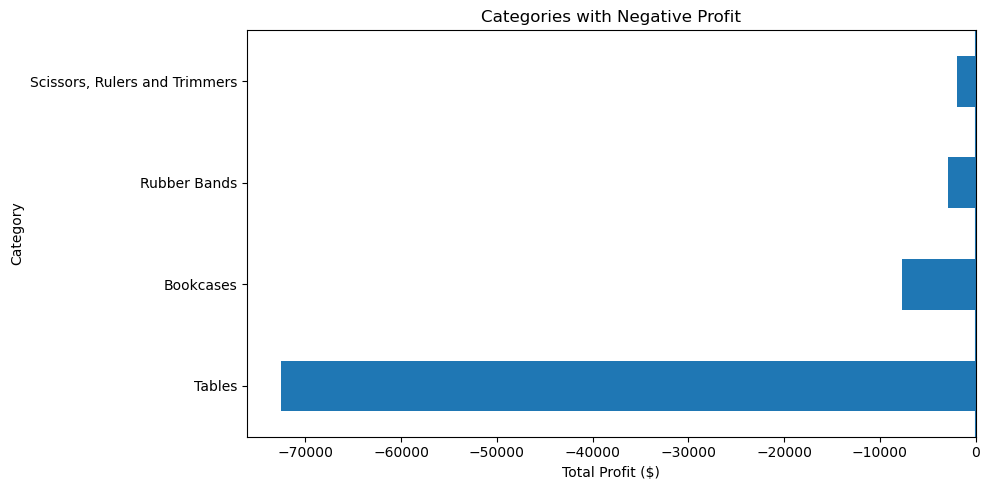

In [68]:
loss_categories.plot(kind="barh", figsize=(10,5))

plt.axvline(0)
plt.title("Categories with Negative Profit")
plt.xlabel("Total Profit ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [69]:
discount_profit = sales.groupby("Discount")["Profit"].mean().sort_index()
discount_profit

Discount
0.00    185.097877
0.01    176.867483
0.02    177.339080
0.03    222.536281
0.04    118.609756
0.05    158.161547
0.06    112.615104
0.07    106.148194
0.08     86.125882
0.09    111.490241
0.10     68.427208
0.11    148.000000
0.16    -75.000000
0.17     -9.000000
0.21    -18.000000
0.25   -481.000000
Name: Profit, dtype: float64

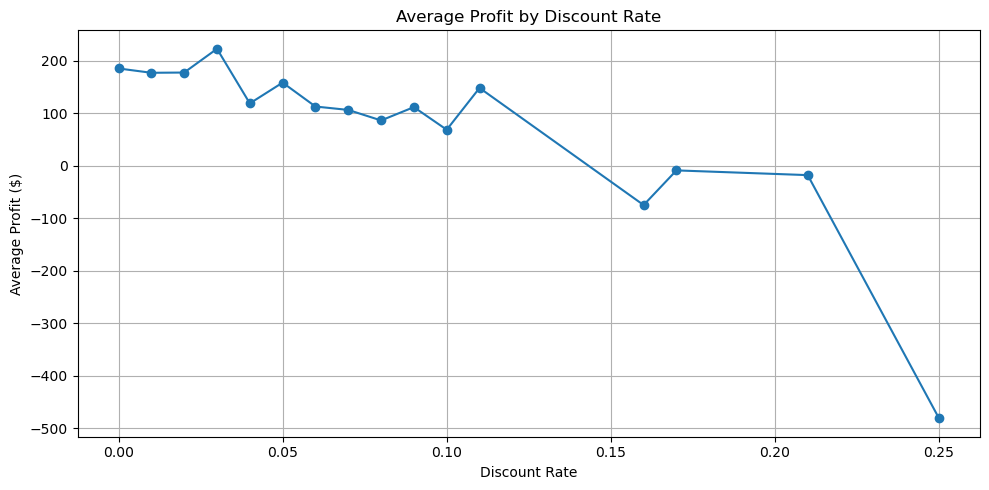

In [70]:
discount_profit.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Average Profit by Discount Rate")
plt.xlabel("Discount Rate")
plt.ylabel("Average Profit ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
top_items_sales = sales.groupby("Item")["Sales"].sum().sort_values(ascending=False).head(10)
top_items_sales

Item
Global Troyô Executive Leather Low-Back Tilter                                 194027
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish                  190195
Canon imageCLASS 2200 Advanced Copier                                          107698
Canon PC1080F Personal Copier                                                  102934
Hewlett-Packard cp1700 [D, PS] Series Color Inkjet Printers                    102888
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    102656
Bretford CR8500 Series Meeting Room Furniture                                  101796
Polycom ViewStationô ISDN Videoconferencing Unit                                92917
Chromcraft Bull-Nose Wood 48" x 96" Rectangular Conference Tables               92209
Sharp AL-1530CS Digital Copier                                                  86057
Name: Sales, dtype: int64

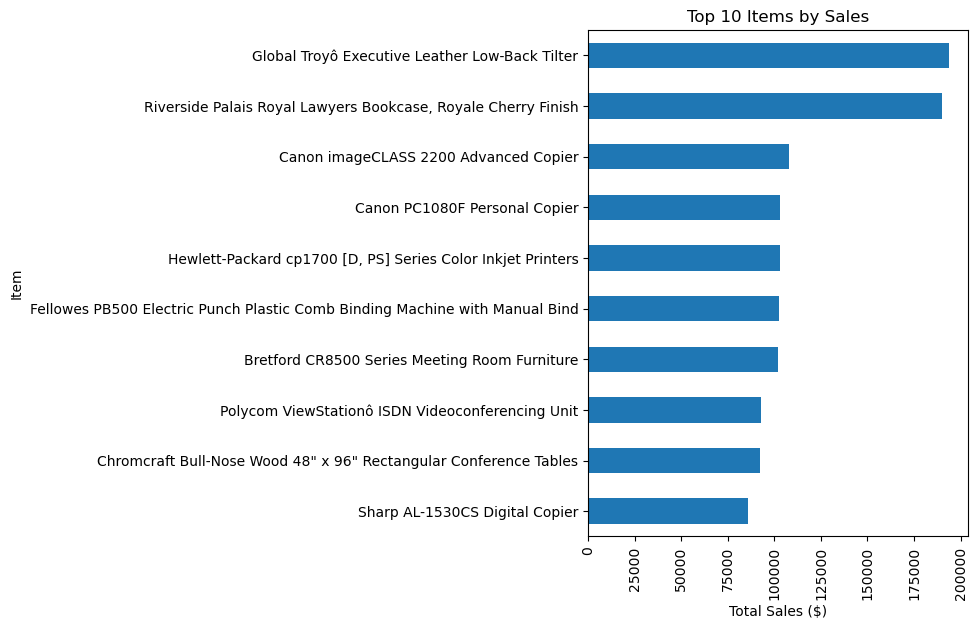

In [74]:
top_items_sales.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Top 10 Items by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Item")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [75]:
least_profitable_items = sales.groupby("Item")["Profit"].sum().sort_values().head(10)
least_profitable_items

Item
Okidata Pacemark 4410N Wide Format Dot Matrix Printer                            -39743
Polycom ViewStationô ISDN Videoconferencing Unit                                 -36447
Epson DFX-8500 Dot Matrix Printer                                                -29557
Global High-Back Leather Tilter, Burgundy                                        -23238
Lesro Sheffield Collection Coffee Table, End Table, Center Table, Corner Table   -14874
Hoover Portapowerô Portable Vacuum                                               -14121
Large Capacity Hanging Post Binders                                              -12443
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables                -11541
KI Conference Tables                                                             -10070
Eldon ClusterMat Chair Mat with Cordless Antistatic Protection                    -9543
Name: Profit, dtype: int64

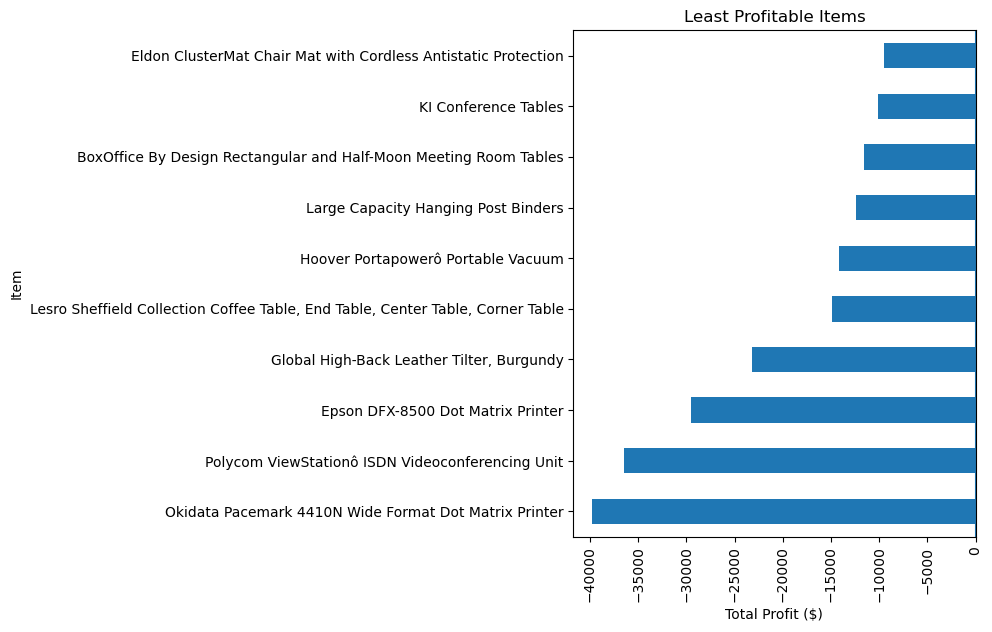

In [77]:
least_profitable_items.plot(kind="barh", figsize=(10,6))

plt.axvline(0)
plt.title("Least Profitable Items")
plt.xlabel("Total Profit ($)")
plt.ylabel("Item")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [78]:
print("INSIGHTS BUSINESS")
print("-----------------")
print(f"Total Sales: {sales['Sales'].sum():,.0f} $")
print(f"Total Profit: {sales['Profit'].sum():,.0f} $")
print(f"Average Shipping Delay: {sales['Shipping Delay'].mean():.1f} days")
print(f"Best Category by Sales: {sales.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Best Category by Profit: {sales.groupby('Category')['Profit'].sum().idxmax()}")
print(f"Best Region by Sales: {sales.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Best Region by Profit: {sales.groupby('Region')['Profit'].sum().idxmax()}")
print(f"Best Customer by Sales: {sales.groupby('Customer Name')['Sales'].sum().idxmax()}")

INSIGHTS BUSINESS
-----------------
Total Sales: 8,952,027 $
Total Profit: 1,312,415 $
Average Shipping Delay: 17.0 days
Best Category by Sales: Office Machines
Best Category by Profit: Telephones and Communication
Best Region by Sales: East
Best Region by Profit: East
Best Customer by Sales: Joshua N. Milligan


In [79]:
sales_clean = sales.copy()

sales_clean.columns = (
    sales_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

sales_clean.head()

,category,city,container,customer_id,customer_name,customer_segment,department,item_id,item,order_date,...,discount,order_quantity,product_base_margin,profit,sales,shipping_cost,unit_price,shipping_delay,order_year,order_month
0,Paper,Lombard,Small Box,3035,Mark Bailey,Home Office,Office Supplies,10074,Hammermill CopyPlus Copy Paper (20Lb. and 84 B...,2016-11-08,...,0.01,10,0.36,-76,53,5,5,1,2016,11
1,Paper,Lombard,Wrap Bag,3035,Mark Bailey,Home Office,Office Supplies,10079,Telephone Message Books with Fax/Mobile Sectio...,2014-11-11,...,0.04,12,0.39,52,76,1,6,1,2014,11
2,Pens & Art Supplies,Southbury,Wrap Bag,3385,Daniel Richmond,Corporate,Office Supplies,11012,"Premium Writing Pencils, Soft, #2 by Central A...",2015-11-23,...,0.04,5,0.57,-22,16,2,3,0,2015,11
3,Binders and Binder Accessories,Coachella,Small Box,3133,Kristine Singleton,Corporate,Office Supplies,10646,Fellowes Black Plastic Comb Bindings,2016-01-13,...,0.10,12,0.39,-350,65,8,6,12,2016,1
4,Rubber Bands,Coachella,Wrap Bag,3133,Kristine Singleton,Corporate,Office Supplies,10138,Assorted Color Push Pins,2016-01-13,...,0.03,10,0.52,4,19,1,2,12,2016,1


In [80]:
sales_clean.to_csv("../cleaned_data/sales_clean.csv", index=False)